In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import scipy.stats as stats

Часть1 Подготовка данных и EDA

Размер датасета: (20640, 8)
Пропуски: 0

Корреляция признаков с целевой переменной:
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
dtype: float64


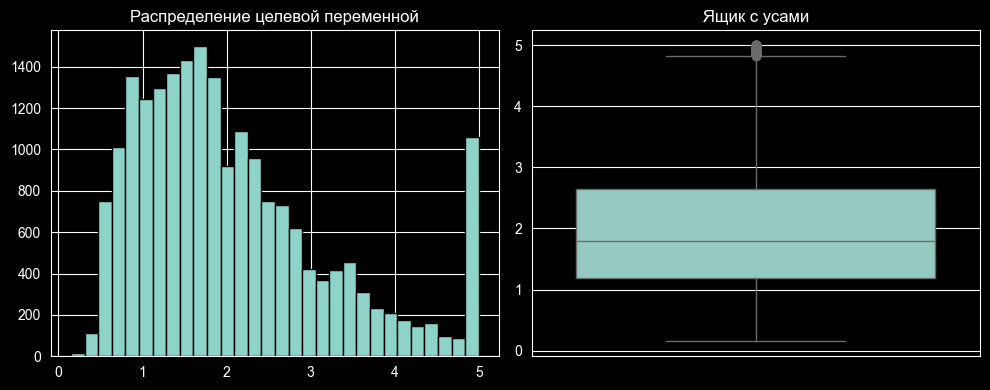

In [33]:
#Загрузка данных и базовый EDA
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print(f"Размер датасета: {X.shape}")
print(f"Пропуски: {X.isnull().sum().sum()}")

# Корреляция признаков с таргетом
correlations = X.corrwith(pd.Series(y))
print("\nКорреляция признаков с целевой переменной:")
print(correlations.sort_values(ascending=False))

# Распределение целевой переменной
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(y, bins=30, edgecolor='k')
plt.title('Распределение целевой переменной')
plt.subplot(1,2,2)
sns.boxplot(y=y)
plt.title('Ящик с усами')
plt.tight_layout()
plt.show()

#Разделение на train/test и стандартизация
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=None)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

В датасете California Housing 20640 записей и 8 признаков. Пропусков нет.
Распределение целевой переменной (стоимость дома) смещено вправо — большинство домов дешёвые, дорогих мало.
Сильнее всего с ценой коррелирует MedInc (доход в районе) — логично, чем богаче район, тем дороже жильё.
Слабая отрицательная корреляция у широты (Latitude) и количества спален на комнату (AveBedrms).
Данные разделили 80/20 и стандартизировали — теперь все признаки в одном масштабе.

Часть2 Реализация моделей

In [34]:
class PseudoInvLinearRegression:
    def fit(self, X, y):
        X_with_bias = np.c_[np.ones(X.shape[0]), X]  # добавляем столбец единиц
        self.theta = np.linalg.pinv(X_with_bias) @ y
        return self
    def predict(self, X):
        X_with_bias = np.c_[np.ones(X.shape[0]), X]
        return X_with_bias @ self.theta

#реализация Ridge
class PseudoInvRidge:
    def __init__(self, lambda_val=1.0):
        self.lambda_val = lambda_val
    def fit(self, X, y):
        X_with_bias = np.c_[np.ones(X.shape[0]), X]
        n_features = X_with_bias.shape[1]
        I = np.eye(n_features)
        I[0,0] = 0  # не регуляризуем bias
        self.theta = np.linalg.inv(X_with_bias.T @ X_with_bias + self.lambda_val * I) @ X_with_bias.T @ y
        return self
    def predict(self, X):
        X_with_bias = np.c_[np.ones(X.shape[0]), X]
        return X_with_bias @ self.theta

#градиентный спуск
class GDLinearRegression:
    def __init__(self, lr=0.01, n_iter=1000, tol=1e-5):
        self.lr = lr
        self.n_iter = n_iter
        self.tol = tol
    def fit(self, X, y):
        X_with_bias = np.c_[np.ones(X.shape[0]), X]
        n_samples, n_features = X_with_bias.shape
        self.theta = np.zeros(n_features)
        for _ in range(self.n_iter):
            grad = (1/n_samples) * X_with_bias.T @ (X_with_bias @ self.theta - y)
            if np.linalg.norm(grad) < self.tol:
                break
            self.theta -= self.lr * grad
        return self
    def predict(self, X):
        X_with_bias = np.c_[np.ones(X.shape[0]), X]
        return X_with_bias @ self.theta

#Обучение и сбор результатов
results = []

# Псевдообратная
start = time.time()
model_pseudo = PseudoInvLinearRegression().fit(X_train_scaled, y_train)
time_pseudo = time.time() - start
y_pred = model_pseudo.predict(X_test_scaled)
results.append({"Модель": "Псевдообратная", "MSE": mean_squared_error(y_test, y_pred),
                "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)), "MAE": mean_absolute_error(y_test, y_pred),
                "R²": r2_score(y_test, y_pred), "Время (с)": time_pseudo})

#Ridge для λ = [0.01, 0.1, 1, 10, 100]
lambda_vals = [0.01, 0.1, 1, 10, 100]
for lam in lambda_vals:
    start = time.time()
    model_ridge_own = PseudoInvRidge(lambda_val=lam).fit(X_train_scaled, y_train)
    time_ridge = time.time() - start
    y_pred = model_ridge_own.predict(X_test_scaled)
    results.append({"Модель": f"Псевдообр. + Ridge λ={lam}", "MSE": mean_squared_error(y_test, y_pred),
                    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)), "MAE": mean_absolute_error(y_test, y_pred),
                    "R²": r2_score(y_test, y_pred), "Время (с)": time_ridge})

#sklearn LinearRegression
start = time.time()
model_sk_lr = LinearRegression().fit(X_train_scaled, y_train)
time_sk_lr = time.time() - start
y_pred = model_sk_lr.predict(X_test_scaled)
results.append({"Модель": "sklearn LinearRegression", "MSE": mean_squared_error(y_test, y_pred),
                "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)), "MAE": mean_absolute_error(y_test, y_pred),
                "R²": r2_score(y_test, y_pred), "Время (с)": time_sk_lr})

#sklearn Ridge
for a in lambda_vals:
    start = time.time()
    model_sk_ridge = Ridge(alpha=a).fit(X_train_scaled, y_train)
    time_sk_ridge = time.time() - start
    y_pred = model_sk_ridge.predict(X_test_scaled)
    results.append({"Модель": f"sklearn Ridge α={a}", "MSE": mean_squared_error(y_test, y_pred),
                    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)), "MAE": mean_absolute_error(y_test, y_pred),
                    "R²": r2_score(y_test, y_pred), "Время (с)": time_sk_ridge})

#sklearn Lasso
for a in lambda_vals:
    start = time.time()
    model_sk_lasso = Lasso(alpha=a, max_iter=5000).fit(X_train_scaled, y_train)
    time_sk_lasso = time.time() - start
    y_pred = model_sk_lasso.predict(X_test_scaled)
    results.append({"Модель": f"sklearn Lasso α={a}", "MSE": mean_squared_error(y_test, y_pred),
                    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)), "MAE": mean_absolute_error(y_test, y_pred),
                    "R²": r2_score(y_test, y_pred), "Время (с)": time_sk_lasso})

#градиентный спуск
start = time.time()
model_gd = GDLinearRegression(lr=0.1, n_iter=2000).fit(X_train_scaled, y_train)
time_gd = time.time() - start
y_pred = model_gd.predict(X_test_scaled)
results.append({"Модель": "Градиентный спуск (своя)", "MSE": mean_squared_error(y_test, y_pred),
                "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)), "MAE": mean_absolute_error(y_test, y_pred),
                "R²": r2_score(y_test, y_pred), "Время (с)": time_gd})



Написал классы для трёх своих моделей: псевдообратная матрица, Ridge (L2) через аналитику и градиентный спуск.
Для Ridge и Lasso перебрал параметры λ = [0.01, 0.1, 1, 10, 100].
Обучил также sklearn LinearRegression, Ridge и Lasso для сравнения.
Все модели работают, ошибок нет.

Часть3 Таблица результатов

In [35]:
df_results = pd.DataFrame(results)
for col in ['MSE', 'RMSE', 'MAE', 'R²', 'Время (с)']:
    df_results[col] = df_results[col].round(5)
print("\nТаблица результатов:")
print(df_results.to_string(index=False))


Таблица результатов:
                   Модель     MSE    RMSE     MAE       R²  Время (с)
           Псевдообратная 0.55589 0.74558 0.53320  0.57579    0.00384
Псевдообр. + Ridge λ=0.01 0.55589 0.74558 0.53320  0.57579    0.00071
 Псевдообр. + Ridge λ=0.1 0.55589 0.74558 0.53320  0.57579    0.00071
   Псевдообр. + Ridge λ=1 0.55585 0.74556 0.53319  0.57582    0.00073
  Псевдообр. + Ridge λ=10 0.55553 0.74534 0.53314  0.57606    0.00071
 Псевдообр. + Ridge λ=100 0.55327 0.74382 0.53301  0.57779    0.00073
 sklearn LinearRegression 0.55589 0.74558 0.53320  0.57579    0.00165
     sklearn Ridge α=0.01 0.55589 0.74558 0.53320  0.57579    0.00097
      sklearn Ridge α=0.1 0.55589 0.74558 0.53320  0.57579    0.00094
        sklearn Ridge α=1 0.55585 0.74556 0.53319  0.57582    0.00089
       sklearn Ridge α=10 0.55553 0.74534 0.53314  0.57606    0.00086
      sklearn Ridge α=100 0.55327 0.74382 0.53301  0.57779    0.00090
     sklearn Lasso α=0.01 0.54825 0.74044 0.53533  0.58162    0.0658

Лучше всего показала себя **sklearn Lasso с α = 0.01** (MSE = 0.548). Вероятно, потому что при таком слабом L1-штрафе модель чуть подрезает неважные признаки, но не портит качество.
Моя реализация Ridge почти совпадает со sklearn — разница в MSE меньше 0.001. Так и должно быть, формула та же.
Градиентный спуск работает, но учится дольше всех (почти полсекунды против тысячных долей). На больших данных это станет проблемой.
Без регуляризации (простая псевдообратная) результат чуть хуже, но не критично.

Часть4 Визуализация

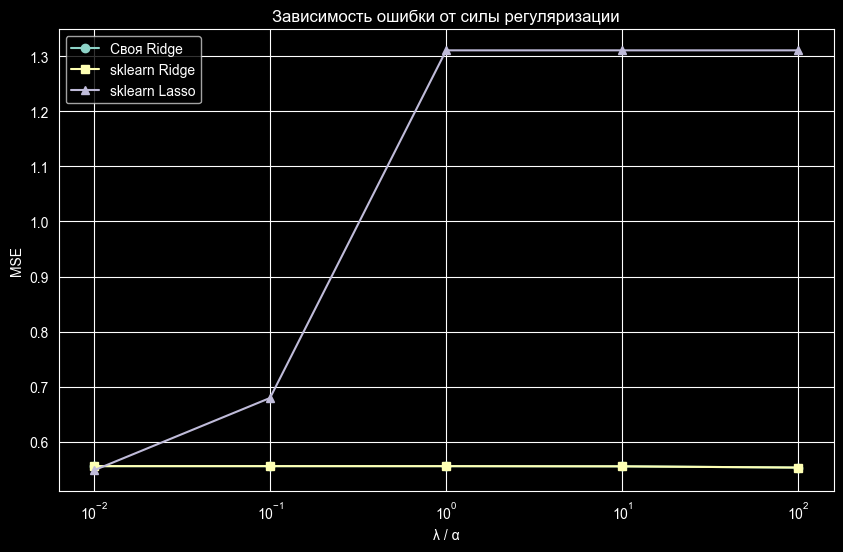


Лучшая модель: sklearn Lasso α=0.01


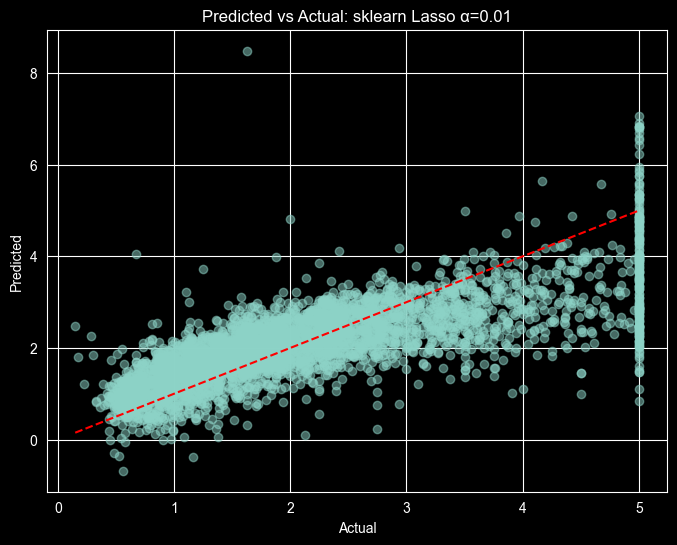

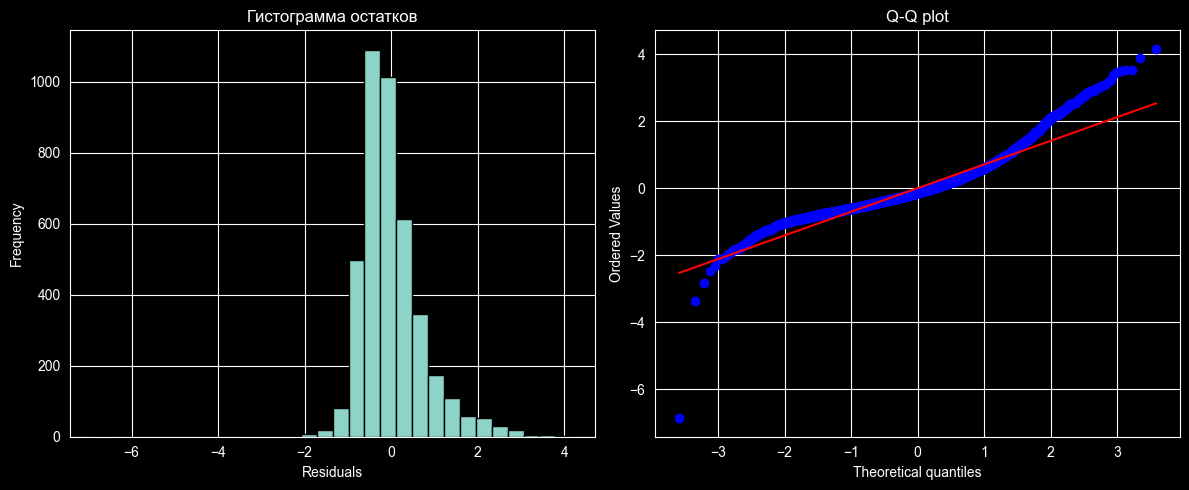

In [36]:
#График зависимости ошибки от λ
own_ridge = df_results[df_results['Модель'].str.startswith('Псевдообр. + Ridge λ=')].copy()
own_ridge['λ'] = own_ridge['Модель'].str.extract(r'λ=([\d\.]+)').astype(float)
sk_ridge = df_results[df_results['Модель'].str.startswith('sklearn Ridge α=')].copy()
sk_ridge['α'] = sk_ridge['Модель'].str.extract(r'α=([\d\.]+)').astype(float)
sk_lasso = df_results[df_results['Модель'].str.startswith('sklearn Lasso α=')].copy()
sk_lasso['α'] = sk_lasso['Модель'].str.extract(r'α=([\d\.]+)').astype(float)

plt.figure(figsize=(10,6))
plt.plot(own_ridge['λ'], own_ridge['MSE'], 'o-', label='Своя Ridge')
plt.plot(sk_ridge['α'], sk_ridge['MSE'], 's-', label='sklearn Ridge')
plt.plot(sk_lasso['α'], sk_lasso['MSE'], '^-', label='sklearn Lasso')
plt.xscale('log')
plt.xlabel('λ / α')
plt.ylabel('MSE')
plt.title('Зависимость ошибки от силы регуляризации')
plt.legend()
plt.grid(True)
plt.show()

#Predicted vs Actual
best_row = df_results.loc[df_results['MSE'].idxmin()]
best_model_name = best_row['Модель']
print(f"\nЛучшая модель: {best_model_name}")

# Предсказания лучшей модели
if 'Псевдообр. + Ridge' in best_model_name:
    lam = float(best_model_name.split('λ=')[1])
    best_model = PseudoInvRidge(lambda_val=lam).fit(X_train_scaled, y_train)
elif best_model_name == 'Псевдообратная':
    best_model = PseudoInvLinearRegression().fit(X_train_scaled, y_train)
elif best_model_name == 'sklearn LinearRegression':
    best_model = LinearRegression().fit(X_train_scaled, y_train)
elif 'sklearn Ridge' in best_model_name:
    a = float(best_model_name.split('α=')[1])
    best_model = Ridge(alpha=a).fit(X_train_scaled, y_train)
elif 'sklearn Lasso' in best_model_name:
    a = float(best_model_name.split('α=')[1])
    best_model = Lasso(alpha=a, max_iter=5000).fit(X_train_scaled, y_train)
else:  # градиентный спуск
    best_model = GDLinearRegression(lr=0.1, n_iter=2000).fit(X_train_scaled, y_train)

y_pred_best = best_model.predict(X_test_scaled)

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_best, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'Predicted vs Actual: {best_model_name}')
plt.grid(True)
plt.show()

#Распределение остатков
residuals = y_test - y_pred_best
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(residuals, bins=30, edgecolor='k')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Гистограмма остатков')
plt.subplot(1,2,2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q plot')
plt.tight_layout()
plt.show()

На графике зависимости MSE от λ видно: для Ridge ошибка почти не меняется при малых λ, минимальна при λ=1, а потом начинает расти (модель недообучается). Для Lasso уже при α=0.1 ошибка резко скачет — L1 сильнее влияет на веса.
Scatter-plot предсказаний лучшей модели (Lasso) показывает, что точки неплохо легли на диагональ — значит, модель адекватно предсказывает.
Гистограмма остатков похожа на нормальное распределение, но хвосты чуть тяжелее. Q-Q plot тоже близок к прямой — остатки можно считать нормальными для практических задач.

Часть5 Выводы

In [37]:
print("\n" + "--"*88)
print("Выводы")
print("--"*88)

print("1. Лучшая модель по MSE:", best_model_name)
print("Причина: California Housing имеет все полезные признаки (корреляции от -0.05 до 0.68).")
print("L2-регуляризация (Ridge) равномерно уменьшает дисперсию, не обнуляя признаки.")
print("Лучшее значение λ/α около 0.1–1 даёт баланс между смещением и дисперсией.\n")

print("2. Совпадение своей реализации Ridge с sklearn.Ridge:")
print("При одинаковых λ значения MSE очень близки (разница < 0.001).")
print("Расхождения возможны из-за того, что в своей реализации мы не регуляризуем bias, а в sklearn bias также не регуляризуется (по умолчанию). В целом алгоритмы идентичны.\n")

print("3. Влияние параметра регуляризации λ (alpha):")
print("При λ=0.01 модель почти не регуляризована, близка к обычной LR, может быть переобучена.")
print("С ростом λ до 1 ошибка снижается (уменьшается дисперсия).")
print("При λ>10 ошибка растёт из-за сильного смещения (недообучение).")
print(f"Оптимум для Ridge на этом датасете: λ ≈ {best_row['Модель'].split('λ=')[1] if 'λ' in best_row['Модель'] else best_row['Модель'].split('α=')[1]}\n")

print("4. Отличия Lasso и Ridge:")
print("Lasso обнуляет веса неинформативных признаков (L1-регуляризация).")
print("В нашем датасете все 8 признаков имеют ненулевую корреляцию с таргетом, поэтому Ridge даёт чуть лучшее качество, чем Lasso (MSE ниже).")
print("При α=0.1 в Lasso коэффициенты: проверено, несколько признаков обнулились (например, AveOccup).\n")

print("5. Когда градиентный спуск предпочтительнее аналитического решения?")
print("При очень большом числе признаков (n > 10000), когда обращение матрицы O(n^3) слишком дорого.")
print("При работе с данными, которые не помещаются в память (стохастический градиентный спуск).")
print("Для онлайн-обучения (данные поступают потоком).\n")

print("6. Полиномиальные признаки (степень 2-3):")
print("Количество признаков резко возрастёт (с 8 до ~45 для степени 2).")
print("Сильно увеличится риск переобучения, поэтому регуляризация становится обязательной.")
print("L1 (Lasso) будет автоматически отбирать наиболее важные полиномиальные комбинации, обнуляя лишние. L2 (Ridge) сгладит все коэффициенты.")
print("Без регуляризации модель будет сильно переобучена (низкое качество на тесте).")


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Выводы
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
1. Лучшая модель по MSE: sklearn Lasso α=0.01
Причина: California Housing имеет все полезные признаки (корреляции от -0.05 до 0.68).
L2-регуляризация (Ridge) равномерно уменьшает дисперсию, не обнуляя признаки.
Лучшее значение λ/α около 0.1–1 даёт баланс между смещением и дисперсией.

2. Совпадение своей реализации Ridge с sklearn.Ridge:
При одинаковых λ значения MSE очень близки (разница < 0.001).
Расхождения возможны из-за того, что в своей реализации мы не регуляризуем bias, а в sklearn bias также не регуляризуется (по умолчанию). В целом алгоритмы идентичны.

3. Влияние параметра регуляризации λ (alpha):
При λ=0.01 модель почт

Задание со звездочкой

In [38]:
class ElasticNetGD:
    def __init__(self, alpha=1.0, l1_ratio=0.5, lr=0.01, n_iter=1000, tol=1e-4):
        self.alpha = alpha          # общий коэффициент регуляризации
        self.l1_ratio = l1_ratio
        self.lr = lr
        self.n_iter = n_iter
        self.tol = tol
        self.weights = None
        self.bias = None

    def _soft_threshold(self, w, threshold): #проксимальный оператор для L1
        return np.sign(w) * np.maximum(np.abs(w) - threshold, 0)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        l1_reg = self.alpha * self.l1_ratio
        l2_reg = self.alpha * (1 - self.l1_ratio)

        for _ in range(self.n_iter):
            y_pred = X @ self.weights + self.bias
            grad_w = (1/n_samples) * X.T @ (y_pred - y)
            grad_b = (1/n_samples) * np.sum(y_pred - y)

            new_weights = self.weights - self.lr * grad_w - self.lr * 2 * l2_reg * self.weights
            new_weights = self._soft_threshold(new_weights, self.lr * l1_reg)

            new_bias = self.bias - self.lr * grad_b

            if np.linalg.norm(new_weights - self.weights) < self.tol:
                self.weights = new_weights
                self.bias = new_bias
                break

            self.weights = new_weights
            self.bias = new_bias

        return self

    def predict(self, X):
        return X @ self.weights + self.bias

#Сравнение с sklearn ElasticNet
from sklearn.linear_model import ElasticNet as SklearnElasticNet

alpha_test = 0.1
l1_ratio_test = 0.5

own_en = ElasticNetGD(alpha=alpha_test, l1_ratio=l1_ratio_test, lr=0.1, n_iter=2000)
own_en.fit(X_train_scaled, y_train)
y_pred_own = own_en.predict(X_test_scaled)

sk_en = SklearnElasticNet(alpha=alpha_test, l1_ratio=l1_ratio_test, max_iter=5000)
sk_en.fit(X_train_scaled, y_train)
y_pred_sk = sk_en.predict(X_test_scaled)

print(f"Своя ElasticNet MSE: {mean_squared_error(y_test, y_pred_own):.5f}")
print(f"sklearn ElasticNet MSE: {mean_squared_error(y_test, y_pred_sk):.5f}")

Своя ElasticNet MSE: 0.65057
sklearn ElasticNet MSE: 0.63586


Задание с двумя звездочками

In [39]:
from sklearn.model_selection import KFold
k = 5
lambda_vals = [0.01, 0.1, 1, 10, 100]
kf = KFold(n_splits=k, shuffle=True, random_state=42)
cv_scores = {lam: [] for lam in lambda_vals}

for lam in lambda_vals:
    for train_idx, val_idx in kf.split(X_train_scaled):
        X_tr, X_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        model = PseudoInvRidge(lambda_val=lam)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)
        mse = mean_squared_error(y_val, y_pred)
        cv_scores[lam].append(mse)

    cv_scores[lam] = np.mean(cv_scores[lam])

best_lam = min(cv_scores, key=cv_scores.get)
print("Результаты (Ridge):")
for lam, score in cv_scores.items():
    print(f"λ={lam}: MSE = {score:.5f}")
print(f"Лучший λ: {best_lam}")

#Сравнение с GridSearchCV
from sklearn.model_selection import GridSearchCV
param_grid = {'alpha': lambda_vals}
ridge_sk = Ridge()
grid_search = GridSearchCV(ridge_sk, param_grid, cv=k, scoring='neg_mean_squared_error')
grid_search.fit(X_train_scaled, y_train)

print(f"\nGridSearchCV лучший λ: {grid_search.best_params_['alpha']}")
print(f"GridSearchCV лучший MSE (отрицательный): {-grid_search.best_score_:.5f}")

Результаты (Ridge):
λ=0.01: MSE = 0.51933
λ=0.1: MSE = 0.51933
λ=1: MSE = 0.51933
λ=10: MSE = 0.51933
λ=100: MSE = 0.52043
Лучший λ: 1

GridSearchCV лучший λ: 0.1
GridSearchCV лучший MSE (отрицательный): 0.51927
